In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("dataset/train.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Fill Age with median
df['Age'].fillna(
    df['Age'].median(),
    inplace=True
)

# Fill Embarked with mode
df['Embarked'].fillna(
    df['Embarked'].mode()[0],
    inplace=True
)

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

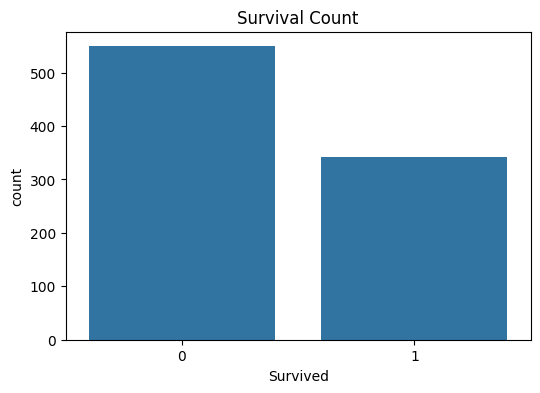

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survival Count")

plt.show()

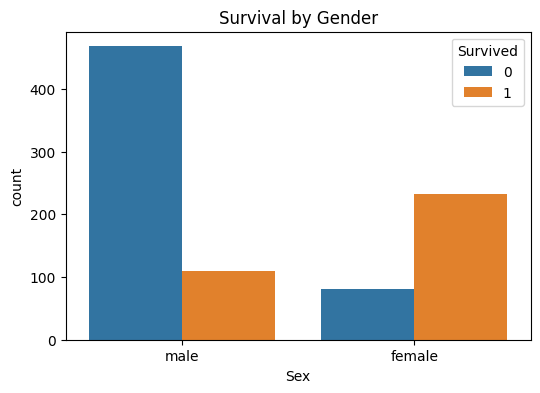

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

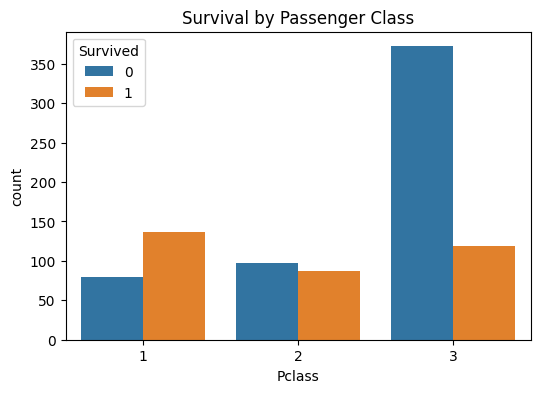

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival by Passenger Class")

plt.show()

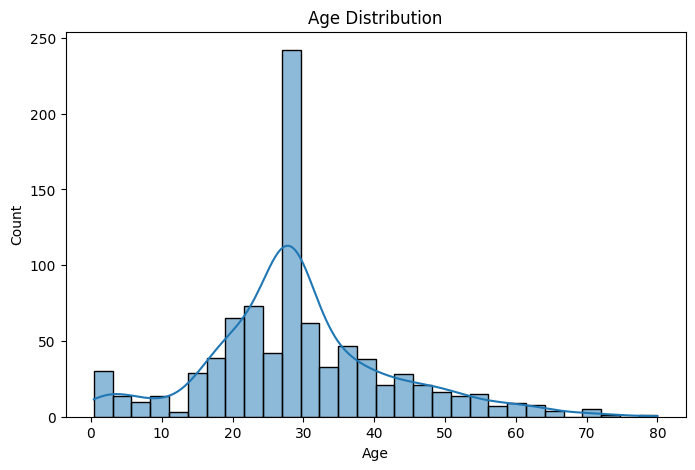

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

In [10]:
df['Sex'] = df['Sex'].map({
    'male':0,
    'female':1
})

df['Embarked'] = df['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

In [11]:
X = df[[
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]]

y = df['Survived']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [14]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[89, 16],
       [20, 54]])

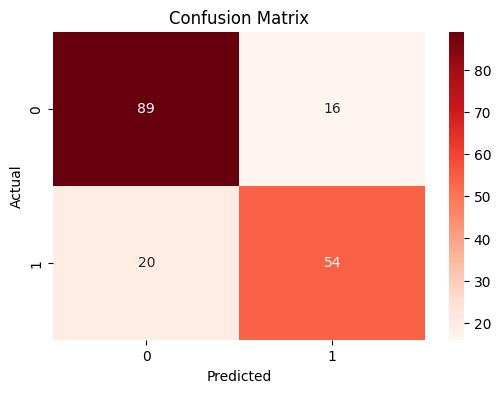

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance

,Feature,Coefficient
0,Pclass,-0.927211
1,Sex,2.601824
2,Age,-0.030262
3,SibSp,-0.299862
4,Parch,-0.090744
5,Fare,0.003039
6,Embarked,0.235201


In [ ]:
#CUSTOM PREDICTION
sample_passenger = [[
    1,      # Pclass
    1,      # Female
    25,     # Age
    0,      # SibSp
    0,      # Parch
    100,    # Fare
    1       # Embarked
]]

prediction = model.predict(sample_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Survived
